# Probiotic field trial data

In [1]:
#load libraries
library(ggplot2)
library(tidyverse)
library(vegan)
library(RColorBrewer)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute



### looking at disease frequency over time in probiotic treated Orbicella's  

3 sites: Rocosa, Plazadetoros, and El Arbol

calculated disease frequency over time for each group and put in a table

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/probiotic_trials")

In [3]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/probiotic_trials"

In [4]:
d_table <- read.table("disease_freq_082526_all.csv", header=TRUE, sep=",")

read.csv didn't work, so I reopened in BBedit and entered the last line. Then used read.table with a sep flag

In [5]:
d_table

day,disease_control,disease_treatment,healthy_control,healthy_treatment
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,100.0,100.0,0.00,0.0
5,100.0,100.0,6.67,0.0
42,71.4,42.9,0.00,0.0
84,57.1,61.5,0.00,0.0
119,64.3,53.8,0.00,14.3


In [6]:
#pivot longer
pivot_table <- d_table %>%
    pivot_longer(-c(day), names_to = "group", values_to = c("disease_freq"))
head(pivot_table)

day,group,disease_freq
<int>,<chr>,<dbl>
1,disease_control,100
1,disease_treatment,100
1,healthy_control,0
1,healthy_treatment,0
5,disease_control,100
5,disease_treatment,100


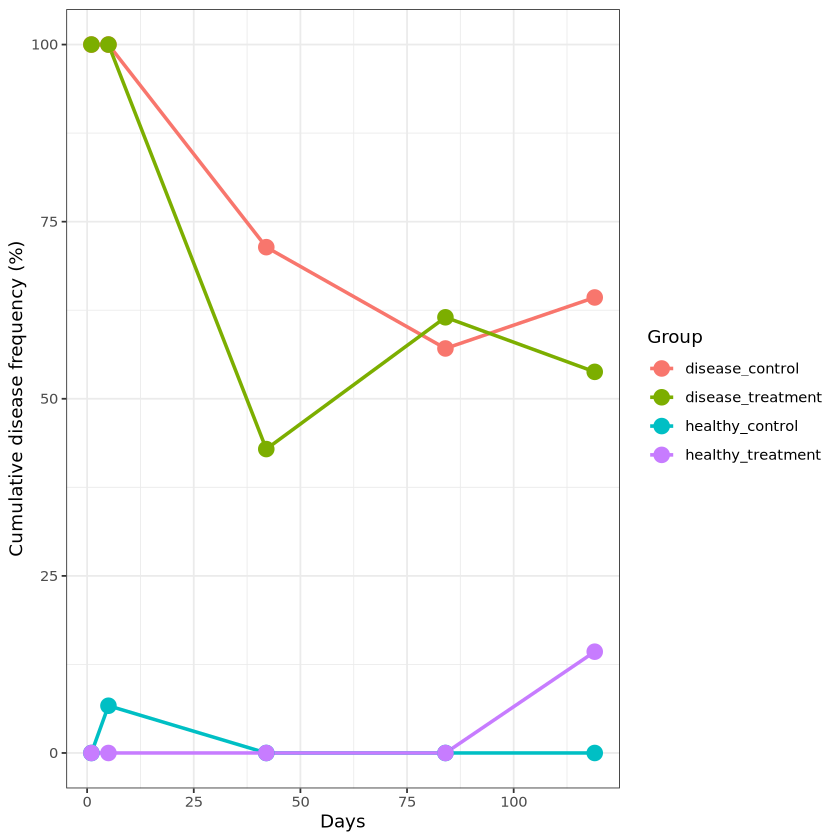

In [7]:
plot1 <- ggplot(pivot_table, aes(x = day, y = disease_freq, color=group)) +
  geom_line(linewidth = 1) +
  geom_point(size = 4)+
  theme_bw() +
  labs(x = "Days", y = "Cumulative disease frequency (%)", color= "Group")
plot1

In [8]:
options(repr.plot.width=8, repr.plot.height=8)

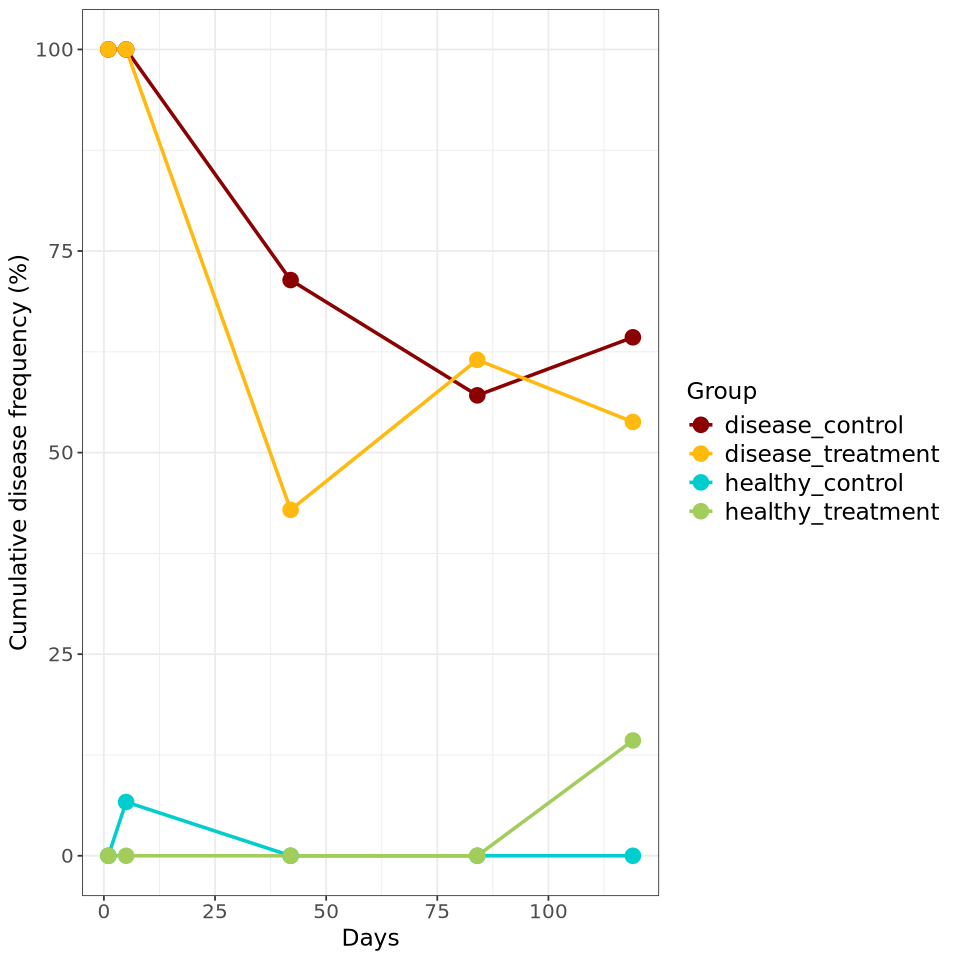

In [9]:
plot2 <- ggplot(pivot_table, aes(x = day, y = disease_freq, color=group)) +
  geom_line(linewidth = 1) +
  geom_point(size = 4)+
 scale_color_manual(values=c("darkred","darkgoldenrod1","cyan3","darkolivegreen3"))+
  theme_bw() +
theme(axis.text.y = element_text(size = 12),
      axis.text.x = element_text(size = 12),
      axis.title.x = element_text(size = 14),
      axis.title.y = element_text(size = 14),
     legend.text = element_text(size = 14),
     legend.title = element_text(size = 14))+
  labs(x = "Days", y = "Cumulative disease frequency (%)", color= "Group")
plot2

In [10]:
ggsave(filename = "Trials_disease_freq_082526.png", plot = plot2, 
      width = 8,
      height = 8,
      units = "in",
      dpi = 300)

### now do just SCTLD (not including YBD as disease)

In [11]:
d1_table <- read.table("disease_freq_082526_SCTLD.csv", header=TRUE, sep=",")

In [12]:
d1_table

day,disease_control,disease_treatment,healthy_control,healthy_treatment
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,100.0,100.0,0.00,0.0
5,100.0,100.0,6.67,0.0
42,71.4,35.7,0.00,0.0
84,57.1,38.5,0.00,0.0
119,64.3,30.8,0.00,14.3


In [13]:
#pivot longer
pivot_table1 <- d1_table %>%
    pivot_longer(-c(day), names_to = "group", values_to = c("disease_freq"))
head(pivot_table1)

day,group,disease_freq
<int>,<chr>,<dbl>
1,disease_control,100
1,disease_treatment,100
1,healthy_control,0
1,healthy_treatment,0
5,disease_control,100
5,disease_treatment,100


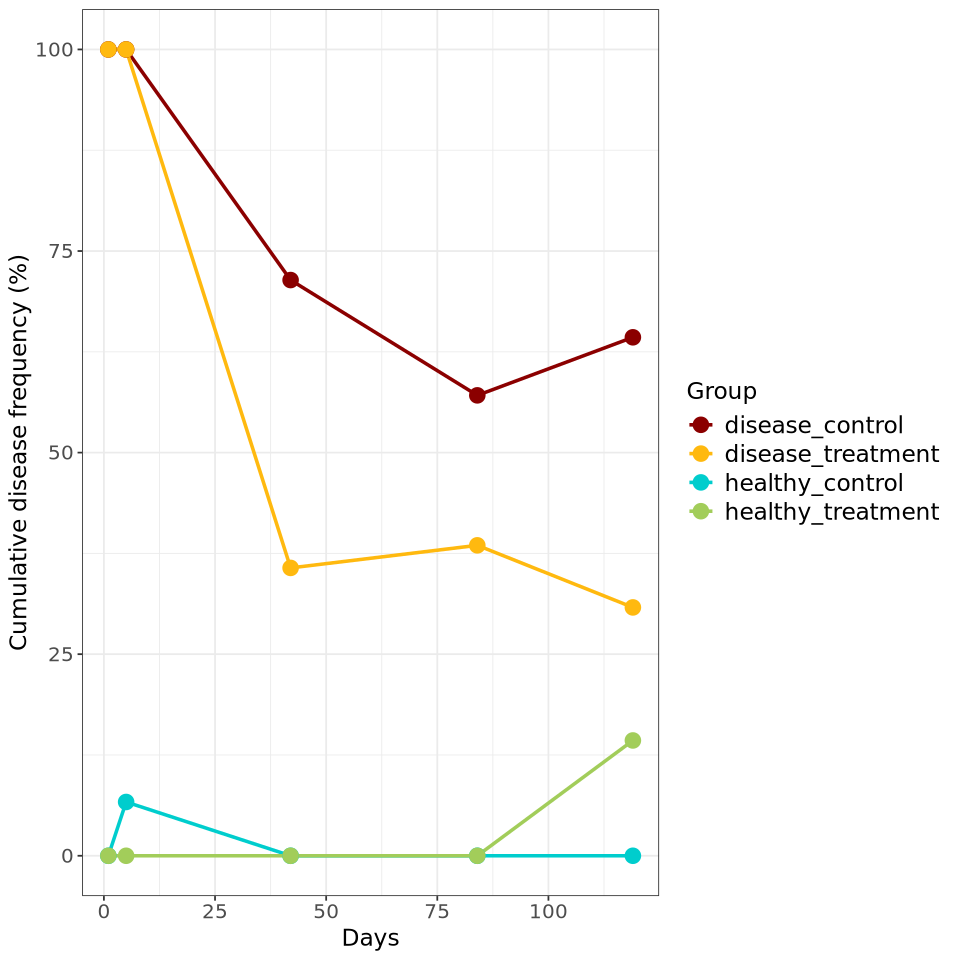

In [14]:
plot3 <- ggplot(pivot_table1, aes(x = day, y = disease_freq, color=group)) +
  geom_line(linewidth = 1) +
  geom_point(size = 4)+
 scale_color_manual(values=c("darkred","darkgoldenrod1","cyan3","darkolivegreen3"))+
  theme_bw() +
theme(axis.text.y = element_text(size = 12),
      axis.text.x = element_text(size = 12),
      axis.title.x = element_text(size = 14),
      axis.title.y = element_text(size = 14),
     legend.text = element_text(size = 14),
     legend.title = element_text(size = 14))+
  labs(x = "Days", y = "Cumulative disease frequency (%)", color= "Group")
plot3

In [15]:
ggsave(filename = "Trials_disease_freq_082526_SC.png", plot = plot3, 
      width = 8,
      height = 8,
      units = "in",
      dpi = 300)

## Sankey plots

change kernel to: R[conda env:.conda-devtools]

In [ ]:
#how I made this env (in terminal)
conda create --prefix /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/.conda/envs/devtools 
conda activate /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/.conda/envs/devtools
conda install conda-forge::r-base==4.4.3
conda install r-devtools
conda install jupyter
conda install -c conda-forge r-irkernel
#then move out of terminal and choose R[conda env:.conda-devtools] kernel

In [2]:
install.packages("remotes")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [3]:
devtools::install_github("davidsjoberg/ggsankey")

tidyselect   (NA -> 1.2.1) [CRAN]
generics     (NA -> 0.1.4) [CRAN]
viridisLite  (NA -> 0.4.3) [CRAN]
RColorBrewer (NA -> 1.1-3) [CRAN]
labeling     (NA -> 0.4.3) [CRAN]
farver       (NA -> 2.1.2) [CRAN]
dplyr        (NA -> 1.2.1) [CRAN]
scales       (NA -> 1.4.0) [CRAN]
S7           (NA -> 0.2.2) [CRAN]
isoband      (NA -> 0.3.0) [CRAN]
gtable       (NA -> 0.3.6) [CRAN]
forcats      (NA -> 1.0.1) [CRAN]
tidyr        (NA -> 1.3.2) [CRAN]
ggplot2      (NA -> 4.0.3) [CRAN]


Installing 14 packages: tidyselect, generics, viridisLite, RColorBrewer, labeling, farver, dplyr, scales, S7, isoband, gtable, forcats, tidyr, ggplot2

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpIoKfhM/remotes1702477f7df63f/davidsjoberg-ggsankey-b675d0d/DESCRIPTION’ ... OK
* preparing ‘ggsankey’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘ggsankey_0.0.99999.tar.gz’



In [7]:
install.packages("dplyr", dependencies = TRUE)


also installing the dependency ‘RSQLite’


Warning message in install.packages("dplyr", dependencies = TRUE):
“installation of package ‘RSQLite’ had non-zero exit status”
Warning message in install.packages("dplyr", dependencies = TRUE):
“installation of package ‘dplyr’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [ ]:
install.packages("tidyverse")

In [4]:
install.packages("ggplot2")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [1]:
#load packages
library(dplyr)
library(tidyverse)
library(ggplot2)
library(ggsankey)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




ERROR: Error in library(tidyverse): there is no package called ‘tidyverse’


just did in R studio because couldn't get to work here.